# Phase 3.0: Data Purification & Space-Time Consistency Pipeline

### Module Objective
The main goal of this notebook is to audit, structure, and export the final dataset that will feed our advanced predictive and econometric models in Phase 3. We will work directly with two main fact tables from our Data Warehouse: **`fact_market_balance`** and **`fact_trips`**. These tables contain the three official time-series of our ecosystem: Absolute Demand, Fulfilled Demand, and Latent Demand.

Using a modular pipeline, we will use **DuckDB** as a high-speed extraction engine to transfer our Apache Parquet assets into **Pandas in Python**. In this phase, we will ensure referential integrity, standardize data types, and most importantly, fix the continuity of the 5-minute chronological grids across the entire Uber H3 geographical matrix before running any predictive analysis.


In [1]:
# ==============================================================================
# ENVIRONMENT INITIALIZATION & ANALYTICAL CLIENT PROVISIONING
# Objective: Load core data manipulation and visualization frameworks, and
# instantiate the high-performance in-memory DuckDB relational client.
# ==============================================================================

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Pandas environment to match professional IDE/VSC print layouts
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("[SYSTEM] Initializing clean-slate in-memory DuckDB client...")
# Opens a zero-latency memory connection to run high-speed SQL queries
con = duckdb.connect(database=':memory:')

# Lock the verified absolute infrastructure paths discovered in your audit
FACTS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts"
DIMENSIONS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/dimensions"

print("[SUCCESS] Analytical environment initialized. System variables secured.")


[SYSTEM] Initializing clean-slate in-memory DuckDB client...
[SUCCESS] Analytical environment initialized. System variables secured.


In [2]:
# ==============================================================================
# DATA PIPELINE TRANSITION (PARQUET TO PANDAS DATAFRAMES)
# Objective: Stream the full data warehouse fact tables from disk straight
# into volatile RAM using conformed naming conventions for purification.
# ==============================================================================

print("[DATA ENGINE] Streaming production warehouse facts into pure Python...")

# 1. Transition Hecho C: Matriz Macro de Oferta y Demanda
query_market = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_market_balance.parquet');"
df_fact_market_balance = con.execute(query_market).df()

# 2. Transition Hecho A: Detalle de Conversiones de Viajes Operativos
query_trips = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_trips.parquet');"
df_fact_trips = con.execute(query_trips).df()

print("\n" + "="*80)
print("PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED")
print("="*80)
print(f" ✔ df_fact_market_balance | Shape: {df_fact_market_balance.shape[0]:,} rows x {df_fact_market_balance.shape[1]} columns")
print(f" ✔ df_fact_trips          | Shape: {df_fact_trips.shape[0]:,} rows x {df_fact_trips.shape[1]} columns")
print("-" * 80)
print("[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.")


[DATA ENGINE] Streaming production warehouse facts into pure Python...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED
 ✔ df_fact_market_balance | Shape: 733,830 rows x 6 columns
 ✔ df_fact_trips          | Shape: 4,393,787 rows x 12 columns
--------------------------------------------------------------------------------
[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.


In [3]:
df_fact_market_balance.head(1)

,timestamp_5min,h3_cell,drivers_available_count,total_searches,total_abandoned_searches,avg_price_quoted
0,2026-03-13 08:25:00,618287667201966079,63,41,6,83.15


In [12]:
df_fact_market_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733830 entries, 0 to 733829
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp_5min            733830 non-null  datetime64[us]
 1   h3_cell                   733830 non-null  uint64        
 2   drivers_available_count   733830 non-null  int64         
 3   total_searches            733830 non-null  int64         
 4   total_abandoned_searches  733830 non-null  int64         
 5   avg_price_quoted          733830 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), uint64(1)
memory usage: 33.6 MB


De una eploración inicial obtenemos que respecto a la tabla fact_market_balance,en general no tiene valores nulos y esta en aparente buen tipado, particularmente en las 2 variables que son de especial interes para nosotros: total_searches y total_abandoned_searches.

In [18]:
df_fact_market_balance[['total_searches', 'total_abandoned_searches']].describe()

,total_searches,total_abandoned_searches
count,733830.000000,733830.000000
mean,7.231090,1.243618
std,9.247322,3.111498
min,0.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,9.000000,1.000000
max,62.000000,50.000000


Derivado de un bosquejo estadístico básico, en ambas variables que generarán nuestras series de tiempo, para total_searches tenemos una fuerte dispersión en los datos, así como que la media y la mediana están considerablemente alejadas para la cantidad de datos que se tienen, el max de 62 busquedas exhibe el maximo registrado lo cuál refleja el comportamiento de desesperación, urgencia y también una problemática entre la oferta pq si la demanda esta así entonces no hay una muy buena oferta del todo.
Vale la pena verificar mediante Boxplot para verificar que tanto peso tienen las colas en esta distribución de demanda a lo largo de todo el mes de Marzo. 

Para la variable total_abandoned_searches se tiene algo similar, la media y mediana difieren, la cantidad máxima de abandonos refleja que hay ocaciones donde posiblemente la oferta no sea de lo mejor posible. Lo que es relativamente bueno es que por debajo del 75% de los datos en ambos casos en total_abandoned_searches esta por debajo de 1 lo cual nos dice que el margen de error con el que trabaja la empresa existe y no es tan malo, nosotros veremos si es que lo podemos optimizar.

Ahora para confirmar esto valdría la pena checar las asimetrías, curtosis y ect,.. para verificar que es mejor si usar la media o mediana en ambos casos.
Algo que llama la atención es que existe un total_searches de 0 ie existió algún punto en el tiempo donde la demanda neta fue cero, habrá que verificar como se comportó el avg_price_quoted a continuación. además, entonces eso exibe que la oferta no se sincronizó con la demanda almenos hablando de densidades

In [34]:
# veamos cuantos registros tenemos que cumplen con que la demanda neta fue cero:
df_fact_market_balance[df_fact_market_balance['total_searches']==0].count()

timestamp_5min              140454
h3_cell                     140454
drivers_available_count     140454
total_searches              140454
total_abandoned_searches    140454
avg_price_quoted            140454
dtype: int64

Vemos de manera alarmante que un poco menos de 1/3 de la oferta se desperdicio en el mes, eso ya es más como BI pero bueno valía la pena verlo además, quería hacer un total de oferta vs el total de NO demanda pero no me salió:

In [33]:
sin_busquedas= df_fact_market_balance[df_fact_market_balance['total_searches']==0].count()
total_oferta = df_fact_market_balance['drivers_available_count'].sum()

oferta_vacia = {(
    'sin_busquedas': 'total_sin_demanda',
    'total_oferta': 'total_demanda_ofrecida'
)}

oferta_vacia

SyntaxError: invalid syntax (980128256.py, line 5)

In [29]:
#para ver cuantos no cumplen con lo que debería ser en avg cuando total_searches = 0:
df_fact_market_balance[(df_fact_market_balance['total_searches']==0) & (df_fact_market_balance['avg_price_quoted']!=0)].count()

timestamp_5min              0
h3_cell                     0
drivers_available_count     0
total_searches              0
total_abandoned_searches    0
avg_price_quoted            0
dtype: int64

In [ ]:
Por lo menos vemos que no sucede eso de que el precio avg fue distinto de cero cuando el total de busquedas fue cero.

In [35]:
# para ver que onda con la asimetría y la curtosis:
df_fact_market_balance[['total_searches', 'total_abandoned_searches']].skew()

total_searches              1.957215
total_abandoned_searches    6.015156
dtype: float64

De inmediato identificamos que hay desviaciones de cola derecha de manera analítica aunque sea, por lo que nos dice que la distribución de demanda no es uniforme y peor aún la distribución de la demanda o de los precios tampoco porque hay valores altos que arrastran las cancelaciones en los viajes, lo mejor será ver su densidad

In [36]:
df_fact_market_balance[['total_searches', 'total_abandoned_searches']].kurt()

total_searches               3.596934
total_abandoned_searches    45.646511
dtype: float64

Por otra parte vemos que efectivamente en en total de abandonados se tiene una mayor densidad en las colas es decir que es 'normal' que haya un álto número de cancelaciones habrá que analizar si eso le conviene a la empresa o si es consecuencia de un mal precio.

In [37]:
# Solución limpia: Extraemos el conteo escalar usando shape[0]
bloques_sin_demanda = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0].shape[0]

# Calculamos la oferta total acumulada en esos bloques específicos donde nadie buscó viaje
oferta_desperdiciada = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0]['drivers_available_count'].sum()

# Calculamos la oferta total global de todo el mes de Marzo para comparar
total_oferta_global = df_fact_market_balance['drivers_available_count'].sum()

# Creamos el reporte limpio en un diccionario real
reporte_oferta = {
    "total_bloques_sin_demanda": bloques_sin_demanda,
    "conductores_esperando_en_vacio": oferta_desperdiciada,
    "total_conductores_ofertados_mes": total_oferta_global,
    "porcentaje_oferta_ociosa": round((oferta_desperdiciada / total_oferta_global) * 100, 2)
}

print("=== REPORTE OPERATIVO DE EFICIENCIA DE OFERTA ===")
for llave, valor in reporte_oferta.items():
    print(f" -> {llave}: {valor:,}" if type(valor) != float else f" -> {llave}: {valor}%")


=== REPORTE OPERATIVO DE EFICIENCIA DE OFERTA ===
 -> total_bloques_sin_demanda: 140,454
 -> conductores_esperando_en_vacio: 2,044,023
 -> total_conductores_ofertados_mes: 29,690,592
 -> porcentaje_oferta_ociosa: 6.88


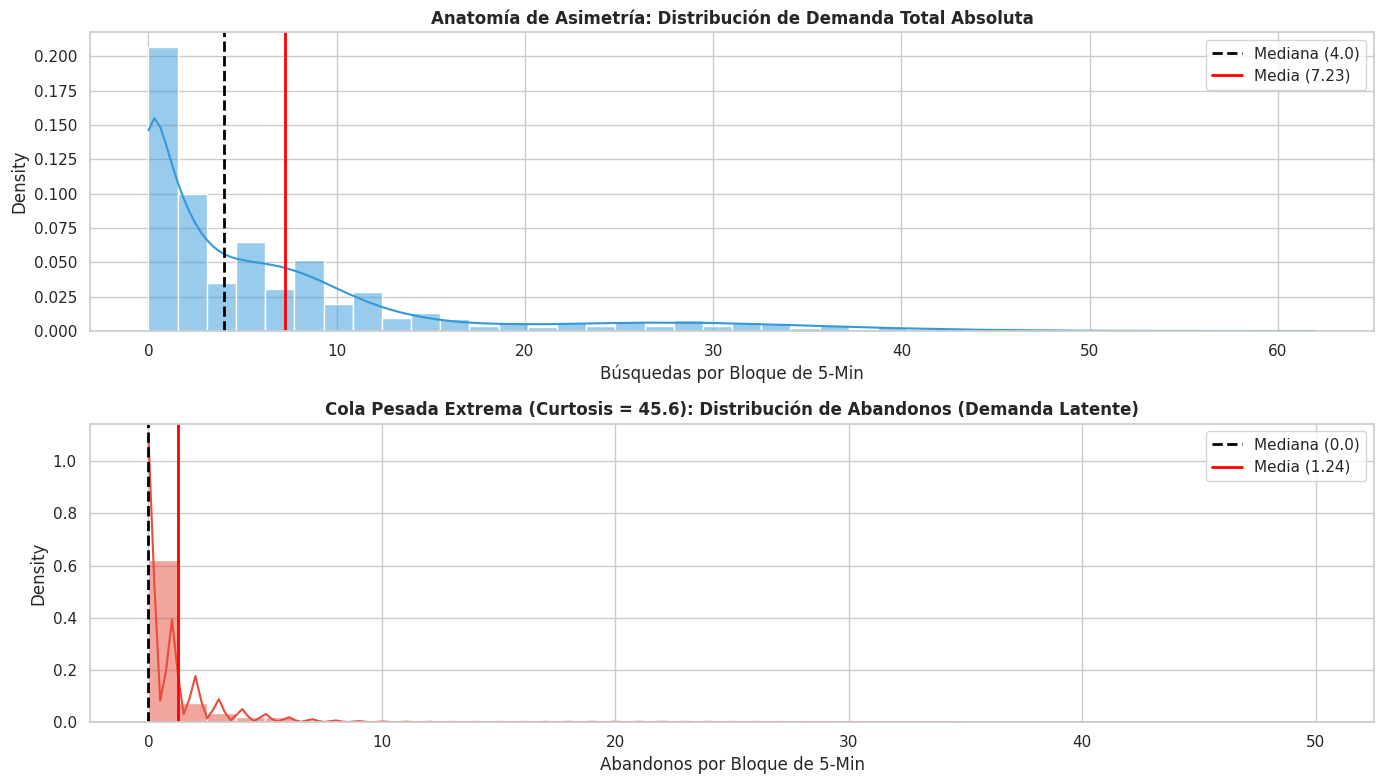

In [38]:
# ==============================================================================
# AUDIT PLOT: LATENT DEMAND & ABSOLUTE DEMAND DENSITY ANATOMY
# Objective: Visualize the massive right-skew and leptokurtic behavior 
# discovered in the skew() and kurt() mathematical audit metrics.
# ==============================================================================

# Configure the high-end grid aesthetic we selected
sns.set_theme(style="whitegrid", context="notebook")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Plot 1: Kernel Density Estimate (KDE) para la Demanda Total
sns.histplot(data=df_fact_market_balance, x='total_searches', ax=ax1, kde=True, color='#3498db', bins=40, stat="density")
ax1.axvline(df_fact_market_balance['total_searches'].median(), color='black', linestyle='--', linewidth=2, label=f"Mediana ({df_fact_market_balance['total_searches'].median()})")
ax1.axvline(df_fact_market_balance['total_searches'].mean(), color='red', linestyle='-', linewidth=2, label=f"Media ({df_fact_market_balance['total_searches'].mean():.2f})")
ax1.set_title('Anatomía de Asimetría: Distribución de Demanda Total Absoluta', fontsize=12, fontweight='bold')
ax1.set_xlabel('Búsquedas por Bloque de 5-Min')
ax1.legend()

# Plot 2: KDE para la Demanda Latente (El monstruo de la Curtosis de 45)
sns.histplot(data=df_fact_market_balance, x='total_abandoned_searches', ax=ax2, kde=True, color='#e74c3c', bins=40, stat="density")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].median(), color='black', linestyle='--', linewidth=2, label=f"Mediana ({df_fact_market_balance['total_abandoned_searches'].median()})")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].mean(), color='red', linestyle='-', linewidth=2, label=f"Media ({df_fact_market_balance['total_abandoned_searches'].mean():.2f})")
ax2.set_title('Cola Pesada Extrema (Curtosis = 45.6): Distribución de Abandonos (Demanda Latente)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Abandonos por Bloque de 5-Min')
ax2.legend()

plt.tight_layout()
plt.show()


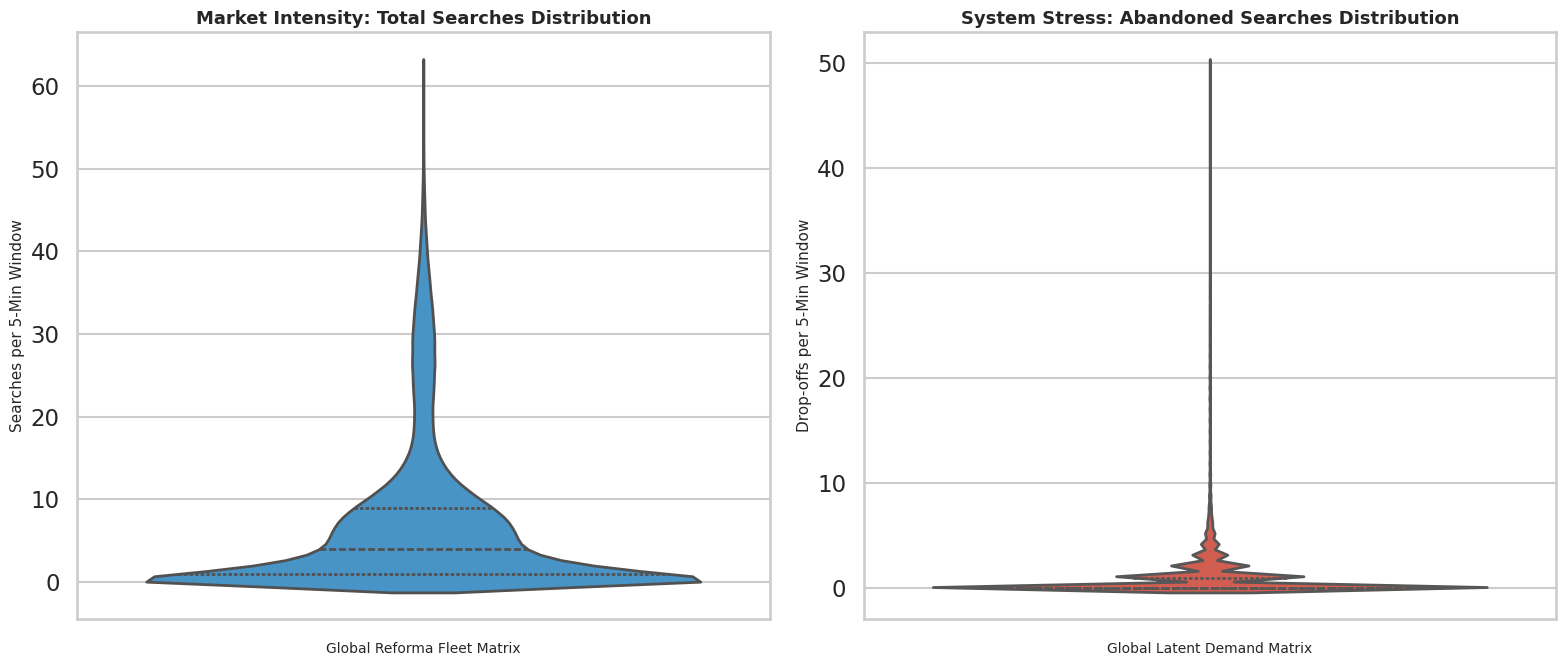

In [39]:
# ==============================================================================
# AUDIT PLOT: GEOMETRICAL VIOLIN ANATOMY FOR MARKETPLACE ASYMMETRY
# Objective: Deploy vertical violin plots to capture the expansive right-skew
# and expose hidden outlier density tails in searches and abandonments.
# ==============================================================================

# Keep our premium whitegrid aesthetic
sns.set_theme(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# ------------------------------------------------------------------------------
# VIOLIN 1: TOTAL ABSOLUTE DEMAND (Búsquedas Brutas)
# ------------------------------------------------------------------------------
sns.violinplot(
    data=df_fact_market_balance, 
    y='total_searches', 
    ax=ax1, 
    color='#3498db',
    inner="quartile",  # Draws dashed lines for 25%, 50% (median), and 75%
    linewidth=2
)
ax1.set_title('Market Intensity: Total Searches Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Searches per 5-Min Window', fontsize=11)
ax1.set_xlabel('Global Reforma Fleet Matrix', fontsize=10)

# ------------------------------------------------------------------------------
# VIOLIN 2: LATENT UNSATISFIED DEMAND (El monstruo de la Curtosis de 45.6)
# ------------------------------------------------------------------------------
sns.violinplot(
    data=df_fact_market_balance, 
    y='total_abandoned_searches', 
    ax=ax2, 
    color='#e74c3c',
    inner="quartile",
    linewidth=2
)
ax2.set_title('System Stress: Abandoned Searches Distribution', fontsize=13, fontweight='bold')
ax2.set_ylabel('Drop-offs per 5-Min Window', fontsize=11)
ax2.set_xlabel('Global Latent Demand Matrix', fontsize=10)

plt.tight_layout()
plt.show()
